# Dose-response BO — fast diagnostic notebook

Stripped-down version of `bo_erk_dose_response_v1.ipynb` for verifying the Bayesian optimisation pipeline runs end-to-end **without burning a 31-min phase per iteration**.

**Compressed phase layout (per FOV):**
1. **2 frames baseline** (no stim)
2. **1 stim frame** at frame 2 with `pulse_duration` ms exposure
3. **2 frames observation** (no stim)

Total **5 frames** at 1 frame/min = **~5 min/phase**.

**Why this notebook exists.** The full v1 protocol takes ~31 min/phase, so iterating on GP / acquisition bugs is slow. This version reproduces every code path (FOVFinder → MDA acquisition → segmentation → tracking → ref-frame extraction → `_preprocess_results` → ExactGP fit per task per candidate → joint pure-exploration acquisition) on a fraction of the timeline.

**What to verify here, in order:**
1. `_preprocess_results` writes `df_results` with no `optortk_expression == 0` rows.
2. After phase 0, the GP fits all 3 candidates per task without `KeyError: 'vmax'` (or any other key) — confirms the gpax mean-fn naming fix.
3. Joint pure-exploration acquisition picks a next pulse_duration without a `ValueError: invalid covariance_matrix`.
4. Phase 1 runs to completion, `df_results` accumulates, hypothesis log-evidence updates per task.
5. By phase 2 each task has locked in a hypothesis and the GP fit reuses it.

If any of those fail here, fix the issue and re-run before going back to the long protocol.

**Key knobs (vs. v1):**
- `N_FRAMES_BASELINE=2`, `N_FRAMES_OBSERVATION=2` (was 10, 20)
- `N_PHASES=3`  `n_initial_phases=1`  `n_hypothesis_phases=1` (lock hypothesis after the first BO phase)
- `gp_num_warmup=200`, `gp_num_samples=400` (≈ ⅓ of v1's HMC budget; enough to fit, fast to iterate)
- Storage: `2026-05-04_bo_erk_dose_response_diagnostic` (separate from v1)

In [2]:
import os
import time
import types
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suppress JAX/XLA debug messages
os.environ["JAX_LOG_COMPILES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import jax
import jax.numpy as jnp

jax.config.update("jax_log_compiles", False)
for _name in list(logging.Logger.manager.loggerDict):
    if "jax" in _name or "absl" in _name:
        logging.getLogger(_name).setLevel(logging.WARNING)

# ---------------------------------------------------------------------------
# gpax/numpyro compatibility shim
# ---------------------------------------------------------------------------
# numpyro >= 0.20 removed haiku support from numpyro.contrib.module, but
# gpax 0.1.9 eagerly imports viDKL via gpax/models/__init__.py. We don't
# use viDKL, so we install stubs that raise only if viDKL is actually called.
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError(
        "haiku support was removed from numpyro >= 0.20. "
        "viDKL is not available. Use ExactGP, viGP, or viSparseGP."
    )


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable
# ---------------------------------------------------------------------------

import numpyro
import numpyro.distributions as dist

from faro.core.data_structures import (
    PowerChannel,
    SegmentationMethod,
)
from faro.core.controller import Controller
from faro.core.pipeline import ImageProcessingPipeline
from faro.agents.bo_optimization import (
    BO_Parameter,
    BO_Objective,
    BO_Covariate,
    StandardScalerBounds,
)
from faro.agents.bo_dose_response import DoseResponseBO
import faro.core.utils as utils

In [3]:
from faro.microscope.pertzlab.jungfrau import Jungfrau

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")
mic.mmc.setProperty("TIPFSStatus", "State", "On")

In [ ]:
import napari
from napari_micromanager import MainWindow

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
mm_wdg._mmc = mic.mmc
viewer.window.add_dock_widget(mm_wdg)

In [4]:
# --- Compressed phase layout: 2 baseline + 1 stim + 2 observation = 5 frames ---
TIME_BETWEEN_TIMESTEPS = 60  # seconds (1 frame/min)

N_FRAMES_BASELINE = 2
N_FRAMES_OBSERVATION = 2
N_FRAMES = N_FRAMES_BASELINE + 1 + N_FRAMES_OBSERVATION  # 5
STIM_FRAME = N_FRAMES_BASELINE  # 0-based index of the single stim frame

# --- Plate calibration (saved by pymmcore-widgets MDA plate widget) ---
PLATE_CALIBRATION_PATH = r"./calib_plate_96.json"  # <-- UPDATE if needed

# --- FOV finder knobs ---
FOV_BORDER_UM = 1000.0
FOV_MIN_DISTANCE_UM = 750.0
FOV_MIN_CELLS = 35
FOV_N_CANDIDATES_PER_WELL = 4

# --- Phased FOV layout ---
# Same throughput as v1 (18 FOVs per phase), so a phase fits in one frame interval.
N_CONDITIONS_PER_ITER = 3
WELLS_PER_CONDITION = 2
FOVS_PER_WELL = 3
N_WELLS_PER_PHASE = N_CONDITIONS_PER_ITER * WELLS_PER_CONDITION  # 6
FOVS_PER_CONDITION = WELLS_PER_CONDITION * FOVS_PER_WELL  # 6
N_FOVS = N_CONDITIONS_PER_ITER * FOVS_PER_CONDITION  # 18
N_PHASES = 5  # phase 0 (init) + phase 1 (multi-hypothesis) + phase 2 (locked)

# --- Wells ---
# Pick a small subset; cycle_wells=True so we don't run out across the 3 phases.
WELLS = []
for row in "AB":
    for col in range(2, 8):
        WELLS.append(f"{row}{col}")
WELLS = WELLS[: N_PHASES * N_WELLS_PER_PHASE]

# --- Storage ---
base_path = "E:\\Alex"
experiment_name = "2026-05-04_bo_erk_dose_response_diagnostic"
path = os.path.join(base_path, experiment_name)

# --- Channels (same as v1) ---
stim_channel = PowerChannel(config="CyanStim", exposure=100, group="TTL_ERK", power=10)
imaging_channels = (
    PowerChannel(config="miRFP", exposure=150, group="TTL_ERK", power=95),
    PowerChannel(config="mScarlet3", exposure=150, group="TTL_ERK", power=95),
)
optocheck_channel = PowerChannel(
    config="mCitrine", exposure=600, group="TTL_ERK", power=95
)

print(
    f"DIAGNOSTIC: {N_PHASES} phases x {N_FOVS} FOVs/phase x {N_FRAMES} frames "
    f"= {N_PHASES * N_FOVS * N_FRAMES} total frames; "
    f"~{N_PHASES * N_FRAMES} min total acquisition time."
)

DIAGNOSTIC: 5 phases x 18 FOVs/phase x 5 frames = 450 total frames; ~25 min total acquisition time.


In [5]:
from faro.stimulation.base import StimWholeFOV
from faro.tracking.trackpy import TrackerTrackpy
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.feature_extraction.optocheck import OptoCheckFE
from faro.segmentation.cellpose_v4 import CellposeV4
from faro.core.writers import OmeZarrWriter

segmentator = CellposeV4(
    custom_model_path="E:\\models\\cellpose\\LifeActH2B_mixed_with_only_H2B_v1",
    min_size=100,
)

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=[
        SegmentationMethod(
            name="labels",
            segmentation_class=segmentator,
            use_channel=0,
            save_tracked=True,
        )
    ],
    feature_extractor=FE_ErkKtr("labels"),
    tracker=TrackerTrackpy(search_range=50),
    stimulator=StimWholeFOV(),
    feature_extractor_ref=OptoCheckFE(used_mask="labels"),
)
writer = OmeZarrWriter(storage_path=path)

Directory E:\Alex\2026-05-04_bo_erk_dose_response_diagnostic\tracks already exists


## Candidate mean functions

**Naming convention.** gpax 0.1.x's predict path reconstructs the per-sample params dict from the MCMC trace using the *sample-site name* as the dict key. If `mean_fn_prior` returns a dict whose keys differ from the `numpyro.sample(...)` names, predict raises `KeyError` on the friendly key (e.g. `KeyError: 'vmax'`) even though the fit itself succeeds. We therefore use the **same prefixed name on both sides** (`hill_vmax`, `exp_amp`, `lin_a`, …) — prefixes also avoid colliding with gpax's own kernel hyperparameter names (`k`, `noise`, etc.).

In [6]:
DOSE_COL = 0  # pulse_duration is the only controllable parameter, always col 0


def _shifted_dose(x):
    return jnp.clip(x[:, DOSE_COL] + 1.0, 1e-6, None)


# --- Hill: V_max * d^n / (K^n + d^n) ---
def hill_mean_fn(x, p):
    d = _shifted_dose(x)
    return (
        p["hill_vmax"]
        * d ** p["hill_n"]
        / (p["hill_k"] ** p["hill_n"] + d ** p["hill_n"])
    )


def hill_mean_fn_prior():
    return {
        "hill_vmax": numpyro.sample("hill_vmax", dist.HalfNormal(2.0)),
        "hill_k": numpyro.sample("hill_k", dist.Uniform(0.05, 3.0)),
        "hill_n": numpyro.sample("hill_n", dist.Uniform(0.5, 4.0)),
    }


# --- Exponential saturation: A * (1 - exp(-d / tau)) ---
def exponential_mean_fn(x, p):
    d = _shifted_dose(x)
    return p["exp_amp"] * (1.0 - jnp.exp(-d / p["exp_tau"]))


def exponential_mean_fn_prior():
    return {
        "exp_amp": numpyro.sample("exp_amp", dist.HalfNormal(2.0)),
        "exp_tau": numpyro.sample("exp_tau", dist.Uniform(0.1, 3.0)),
    }


# --- Linear: a * d + b ---
def linear_mean_fn(x, p):
    d = _shifted_dose(x)
    return p["lin_a"] * d + p["lin_b"]


def linear_mean_fn_prior():
    return {
        "lin_a": numpyro.sample("lin_a", dist.Normal(0.0, 2.0)),
        "lin_b": numpyro.sample("lin_b", dist.Normal(0.0, 1.0)),
    }


CANDIDATE_HYPOTHESES_AUC = {
    "hill": (hill_mean_fn, hill_mean_fn_prior),
    "exponential": (exponential_mean_fn, exponential_mean_fn_prior),
    "linear": (linear_mean_fn, linear_mean_fn_prior),
}
CANDIDATE_HYPOTHESES_FRAC = {
    "hill": (hill_mean_fn, hill_mean_fn_prior),
    "exponential": (exponential_mean_fn, exponential_mean_fn_prior),
    "linear": (linear_mean_fn, linear_mean_fn_prior),
}
print(f"AUC candidates:  {list(CANDIDATE_HYPOTHESES_AUC)}")
print(f"Frac candidates: {list(CANDIDATE_HYPOTHESES_FRAC)}")

AUC candidates:  ['hill', 'exponential', 'linear']
Frac candidates: ['hill', 'exponential', 'linear']


## TwoTaskDoseResponseBO subclass

Same code path as v1 (the user's `subclass` cell). Two differences:
1. **Multi-attempt re-read retry** with delays `(0.5, 1.5, 3.0)` s in case the first attempt sees a stale parquet (longer cumulative budget than v1's single 1-second sleep).
2. Adapted to the compressed timing — uses `n_frames_baseline=N_FRAMES_BASELINE` etc. straight from the parameters cell.

In [7]:
from numpyro.infer.util import log_likelihood as _numpyro_log_likelihood


def _logit(p, eps=1e-4):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def _inv_logit(z):
    return 1.0 / (1.0 + np.exp(-np.asarray(z, dtype=float)))


def _log_marginal_likelihood(gp_model, x, y, max_samples=200):
    samples = gp_model.mcmc.get_samples()
    n_total = next(iter(samples.values())).shape[0]
    n_use = min(int(max_samples), int(n_total))
    sub = {k: v[:n_use] for k, v in samples.items()}
    ll = _numpyro_log_likelihood(gp_model.model, sub, x, y)["y"]
    return float(jax.scipy.special.logsumexp(ll) - jnp.log(ll.shape[0]))


def _extract_optortk_vals(df_phase):
    if "ref_mean_intensity" not in df_phase.columns:
        return np.array([])
    s = df_phase.groupby("particle")["ref_mean_intensity"].first().dropna()
    return s[s > 0].values


class TwoTaskDoseResponseBO(DoseResponseBO):
    """Same as v1 but with multi-attempt optoRTK re-read retry."""

    TASKS = ("auc", "frac")

    def __init__(
        self,
        *,
        candidate_hypotheses_auc,
        candidate_hypotheses_frac,
        n_hypothesis_phases=1,
        peak_threshold=1.5,
        peak_min_consecutive_frames=1,  # only 2 obs frames, 2-consec doesn't fit
        gp_kernel="Matern",
        gp_num_warmup=200,
        gp_num_samples=400,
        retry_delays=(0.5, 1.5, 3.0),
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.peak_threshold = float(peak_threshold)
        self.peak_min_consecutive_frames = int(peak_min_consecutive_frames)
        self.gp_kernel = gp_kernel
        self.gp_num_warmup = int(gp_num_warmup)
        self.gp_num_samples = int(gp_num_samples)
        self.n_hypothesis_phases = int(n_hypothesis_phases)
        self.retry_delays = tuple(retry_delays)

        self.task_columns = {"auc": "mean_delta_auc", "frac": "frac_peak_responders"}
        self.task_logit = {"auc": False, "frac": True}
        self.candidate_hypotheses_by_task = {
            "auc": dict(candidate_hypotheses_auc),
            "frac": dict(candidate_hypotheses_frac),
        }
        self._task_state = {
            t: {
                "cumulative_log_evidence": {
                    h: 0.0 for h in self.candidate_hypotheses_by_task[t]
                },
                "n_hypothesis_phases_run": 0,
                "selected_hypothesis": None,
                "hypothesis_log": [],
            }
            for t in self.TASKS
        }
        self._gp_models_by_task = {}
        self._y_scalers_by_task = {}

    # ----- Per-FOV result extraction -----
    def _preprocess_results(self, fov_tracks):
        phase_id = self._current_phase_id
        results = []
        n_optortk_retried = 0
        n_optortk_recovered = 0

        for fov_idx, df_tracks in fov_tracks.items():
            if df_tracks.empty or "particle" not in df_tracks.columns:
                continue
            if "phase_id" in df_tracks.columns:
                df_phase = df_tracks[df_tracks["phase_id"] == phase_id]
                if df_phase.empty:
                    continue
            else:
                df_phase = df_tracks

            params = self._current_condition_map.get(fov_idx)
            if params is None:
                print(f"  Warning: no condition mapping for FOV {fov_idx}, skipping")
                continue

            cnr_col = (
                "cnr"
                if "cnr" in df_phase.columns
                else "cnr_median" if "cnr_median" in df_phase.columns else None
            )
            if cnr_col is None:
                continue

            all_particles = df_phase["particle"].unique()
            n_cells_total = len(all_particles)
            min_frames = int(self.min_track_fraction * self.n_frames)
            frames_per_cell = df_phase.groupby("particle")["fov_timestep"].nunique()

            baseline_df = df_phase[df_phase["fov_timestep"] < self.n_frames_baseline]
            per_cell_baseline = pd.Series(dtype=float)
            if not baseline_df.empty:
                per_cell_baseline = (
                    baseline_df.groupby("particle")[cnr_col].mean().dropna()
                )
            baseline_cnr_fov = (
                float(per_cell_baseline.mean()) if len(per_cell_baseline) > 0 else 0.0
            )

            optortk_vals = _extract_optortk_vals(df_phase)

            valid_particles = set(all_particles)
            valid_particles &= set(frames_per_cell[frames_per_cell >= min_frames].index)
            if self.max_baseline_cnr is not None and len(per_cell_baseline) > 0:
                valid_particles &= set(
                    per_cell_baseline[per_cell_baseline < self.max_baseline_cnr].index
                )

            n_cells = len(valid_particles)
            n_responding = 0
            cell_aucs = []
            obs_start = self.stim_frame + 1
            obs_end = self.n_frames

            for particle, grp in df_phase.groupby("particle"):
                if particle not in valid_particles:
                    continue
                grp = grp.sort_values("fov_timestep")
                bl = grp[grp["fov_timestep"] < self.n_frames_baseline]
                if bl.empty:
                    continue
                baseline_val = bl[cnr_col].mean()
                obs = grp[
                    (grp["fov_timestep"] >= obs_start) & (grp["fov_timestep"] < obs_end)
                ]
                # Diagnostic notebook has only 2 observation frames, so
                # the v1 cutoff (len(obs) < 3) would discard everything.
                if len(obs) < 1:
                    continue

                t_vals = obs["fov_timestep"].values.astype(float)
                delta = obs[cnr_col].values.astype(float) - baseline_val
                cell_aucs.append(
                    float(np.trapezoid(delta, t_vals))
                    if len(delta) >= 2
                    else float(delta[0])
                )

                above = delta > self.peak_threshold
                if self.peak_min_consecutive_frames <= 1:
                    is_responder = bool(np.any(above))
                else:
                    is_responder = False
                    consec = 0
                    for v in above:
                        if v:
                            consec += 1
                            if consec >= self.peak_min_consecutive_frames:
                                is_responder = True
                                break
                        else:
                            consec = 0
                if is_responder:
                    n_responding += 1

            if n_cells < 3 or len(cell_aucs) == 0:
                print(
                    f"  Warning: FOV {fov_idx} has only {n_cells} valid "
                    f"cells (of {n_cells_total} total), skipping"
                )
                continue

            mean_delta_auc = float(np.mean(cell_aucs))
            frac_peak_responders = n_responding / n_cells
            optortk_expression = (
                float(np.mean(optortk_vals)) if len(optortk_vals) > 0 else 0.0
            )

            # Multi-attempt race-condition retry. Each successive retry
            # gives the producer's parquet write more time to flush.
            if not np.isfinite(optortk_expression) or optortk_expression <= 0.0:
                n_optortk_retried += 1
                for _delay in self.retry_delays:
                    time.sleep(_delay)
                    try:
                        df_retry = self.read_tracks(fov_idx, phase_id=phase_id)
                    except Exception:
                        df_retry = pd.DataFrame()
                    if "phase_id" in df_retry.columns:
                        df_retry = df_retry[df_retry["phase_id"] == phase_id]
                    if not df_retry.empty:
                        optortk_vals_retry = _extract_optortk_vals(df_retry)
                        if len(optortk_vals_retry) > 0:
                            expr_retry = float(np.mean(optortk_vals_retry))
                            if np.isfinite(expr_retry) and expr_retry > 0.0:
                                optortk_vals = optortk_vals_retry
                                optortk_expression = expr_retry
                                n_optortk_recovered += 1
                                print(
                                    f"  Recovered optoRTK for FOV {fov_idx} after "
                                    f"{_delay:.1f}s re-read "
                                    f"({len(optortk_vals)} cells, "
                                    f"mean={optortk_expression:.3f})"
                                )
                                break

            if not np.isfinite(optortk_expression) or optortk_expression <= 0.0:
                print(
                    f"  Warning: FOV {fov_idx} has no valid optoRTK "
                    f"expression after {len(self.retry_delays)} retries; skipping"
                )
                continue

            results.append(
                {
                    "pulse_duration": params["pulse_duration"],
                    "n_cells": float(n_cells),
                    "baseline_cnr": baseline_cnr_fov,
                    "optortk_expression": optortk_expression,
                    "mean_delta_auc": mean_delta_auc,
                    "frac_peak_responders": frac_peak_responders,
                }
            )

        if not results:
            print(f"Warning: no valid FOVs in phase {phase_id}")
            return pd.DataFrame()

        df = pd.DataFrame(results)
        print(
            f"  Phase {phase_id}: {len(df)} FOVs, "
            f"mean_delta_auc={df['mean_delta_auc'].mean():.4f}, "
            f"frac_peak_responders={df['frac_peak_responders'].mean():.4f}"
        )
        if n_optortk_retried > 0:
            n_lost = n_optortk_retried - n_optortk_recovered
            print(
                f"  optoRTK re-read retry: recovered "
                f"{n_optortk_recovered}/{n_optortk_retried} FOVs "
                f"({n_lost} still skipped)"
            )
        return df

    # ----- GP fitting / hypothesis selection -----
    def _fit_candidate(self, mean_fn, mean_fn_prior, x, y, rng_key):
        import gpax

        gp_model = gpax.ExactGP(
            input_dim=x.shape[1],
            kernel=self.gp_kernel,
            mean_fn=mean_fn,
            mean_fn_prior=mean_fn_prior,
        )
        gp_model.fit(
            rng_key,
            X=x,
            y=y,
            progress_bar=False,
            num_warmup=self.gp_num_warmup,
            num_samples=self.gp_num_samples,
            print_summary=False,
            jitter=1e-4,
        )
        log_evidence = _log_marginal_likelihood(gp_model, x, y)
        return gp_model, log_evidence

    def _select_or_fit_for_task(self, task, x, y, rng_key):
        state = self._task_state[task]
        candidates = self.candidate_hypotheses_by_task[task]

        if state["selected_hypothesis"] is not None:
            name = state["selected_hypothesis"]
            mean_fn, mean_fn_prior = candidates[name]
            gp_model, log_evidence = self._fit_candidate(
                mean_fn, mean_fn_prior, x, y, rng_key
            )
            print(f"    [{task}: locked={name!r}, log_evidence={log_evidence:+.3f}]")
            return gp_model

        fits = {}
        for name in candidates:
            print(f"    [{task}: fitting candidate {name!r}]")
            mean_fn, mean_fn_prior = candidates[name]
            fits[name] = self._fit_candidate(mean_fn, mean_fn_prior, x, y, rng_key)

        phase_log_evidence = {n: float(le) for n, (_, le) in fits.items()}
        for n, le in phase_log_evidence.items():
            state["cumulative_log_evidence"][n] += le
        state["hypothesis_log"].append(
            (self._current_phase_id, dict(phase_log_evidence))
        )
        state["n_hypothesis_phases_run"] += 1
        print(
            f"    [{task}: phase log-evidence: "
            + ", ".join(f"{n}={v:+.3f}" for n, v in phase_log_evidence.items())
            + "]"
        )
        best_name = max(
            state["cumulative_log_evidence"],
            key=state["cumulative_log_evidence"].get,
        )
        gp_model = fits[best_name][0]
        if state["n_hypothesis_phases_run"] >= self.n_hypothesis_phases:
            state["selected_hypothesis"] = best_name
            print(
                f"    [{task}: LOCKED {best_name!r} after "
                f"{state['n_hypothesis_phases_run']} hypothesis phases]"
            )
        return gp_model

    def _build_y_for_task(self, task, df_results, y_scaler):
        col = self.task_columns[task]
        y_raw = np.asarray(df_results[col].values, dtype=float).reshape(-1, 1)
        if self.task_logit[task]:
            y_raw = _logit(y_raw)
        return y_scaler.fit_transform(y_raw, bounds=None, log_scale=[False])

    # ----- Joint pure-exploration acquisition -----
    def _compute_marginal_variance(
        self, rng_key, gp_model, x_grid, c_samples, x_scaler
    ):
        n_grid = x_grid.shape[0]
        if c_samples is not None:
            n_mc = c_samples.shape[0] if c_samples.ndim > 1 else len(c_samples)
            if c_samples.ndim == 1:
                c_samples = c_samples.reshape(-1, 1)
            x_repeated = jnp.repeat(x_grid, n_mc, axis=0)
            c_tiled = jnp.tile(c_samples, (n_grid, 1))
            x_full = jnp.hstack([x_repeated, c_tiled])
        else:
            n_mc = 1
            x_full = jnp.asarray(x_grid)
        x_full_scaled = x_scaler.transform(x_full)
        mean_pred, y_sampled = gp_model.predict_in_batches(
            rng_key,
            x_full_scaled,
            batch_size=min(1000, x_full_scaled.shape[0]),
            n=self.ei_num_samples,
            noiseless=self.ei_noiseless,
        )
        mean_broadcast = mean_pred[None, None, :]
        y_sampled = jnp.where(jnp.isfinite(y_sampled), y_sampled, mean_broadcast)
        var_flat = jnp.var(y_sampled, axis=(0, 1))
        var_matrix = var_flat.reshape(n_grid, n_mc)
        return jnp.mean(var_matrix, axis=1)

    def _determine_next_parameters(self, df_results, verbose=False):
        import gpax
        import gpax.utils

        cache = getattr(self, "_cached_gp_fit", None)
        is_first_call_in_batch = cache is None

        if cache is not None:
            x_scaler = cache["x_scaler"]
            x = cache["x"]
            rng_key_predict = cache["rng_key_predict"]
            gp_models_by_task = cache["gp_models_by_task"]
            y_scalers_by_task = cache["y_scalers_by_task"]
            print("  [reusing cached two-task GP fits]")
        else:
            x_scaler = StandardScalerBounds()
            bounds, log_scale = self._get_bounds_and_log_scale()
            x_raw = self._extract_x_from_df(df_results)
            x = x_scaler.fit_transform(x_raw, bounds=bounds, log_scale=log_scale)
            rng_key, rng_key_predict = gpax.utils.get_keys()

            gp_models_by_task = {}
            y_scalers_by_task = {}
            for task in self.TASKS:
                print(
                    f"  Fitting task = {task!r} "
                    f"(column = {self.task_columns[task]!r}, "
                    f"logit={self.task_logit[task]})"
                )
                y_scaler = StandardScalerBounds()
                y = self._build_y_for_task(task, df_results, y_scaler)
                gp_models_by_task[task] = self._select_or_fit_for_task(
                    task, x, y, rng_key
                )
                y_scalers_by_task[task] = y_scaler

            self._gp_models_by_task = gp_models_by_task
            self._y_scalers_by_task = y_scalers_by_task
            self.model = gp_models_by_task["auc"]
            self._x_scaler = x_scaler
            self._y_scaler = y_scalers_by_task["auc"]
            self._rng_key_predict = rng_key_predict

            if getattr(self, "_batch_fit_reuse", False):
                self._cached_gp_fit = dict(
                    gp_models_by_task=gp_models_by_task,
                    y_scalers_by_task=y_scalers_by_task,
                    x_scaler=x_scaler,
                    rng_key_predict=rng_key_predict,
                    x=x,
                )

        x_grid_ctrl = self.x_unmeasured.copy()
        cov_grid = (
            self._sample_covariate_grid(df_results)
            if len(self.bo_covariates) > 0
            else None
        )
        per_task_var_z = {}
        for task in self.TASKS:
            v = self._compute_marginal_variance(
                rng_key_predict,
                gp_models_by_task[task],
                x_grid_ctrl,
                cov_grid,
                x_scaler,
            )
            v_std = jnp.std(v)
            v_std = jnp.where(v_std < 1e-12, 1.0, v_std)
            per_task_var_z[task] = (v - jnp.mean(v)) / v_std
        acq_values_total = sum(per_task_var_z.values())

        self._acquisition_used_this_round = "explore_two_task"
        print(
            f"  Two-task explore acq stats: "
            f"min={float(jnp.min(acq_values_total)):.4f}, "
            f"max={float(jnp.max(acq_values_total)):.4f}"
        )
        next_measurement_idx = jnp.argmax(acq_values_total)
        next_parameters = np.asarray(x_grid_ctrl[int(next_measurement_idx)])
        self.x_unmeasured = np.delete(
            self.x_unmeasured, int(next_measurement_idx), axis=0
        )
        self.x_performed_experiments = (
            np.concatenate(
                [self.x_performed_experiments, next_parameters.reshape(1, -1)],
                axis=0,
            )
            if self.x_performed_experiments is not None
            else next_parameters.reshape(1, -1)
        )

        # Stash the plot context (GP fits + acquisition values from this
        # phase\'s first call) so DoseResponseBO\'s _on_phase_complete
        # can render the GP landscape via our two-task `_plot_1d_landscape`
        # override at the end of the class.  Includes back-compat keys
        # (`gp_model`, `y_scaler`, ...) for the base 1-D plot in case the
        # override is missed.
        if is_first_call_in_batch:
            self._last_plot_context = dict(
                df_results=df_results,
                x_scaler=x_scaler,
                rng_key_predict=rng_key_predict,
                gp_models_by_task=gp_models_by_task,
                y_scalers_by_task=y_scalers_by_task,
                x_unmeasured_at_computation=x_grid_ctrl.copy(),
                acq_values_total=np.asarray(acq_values_total),
                gp_model=gp_models_by_task["auc"],
                y_scaler=y_scalers_by_task["auc"],
                acquisition_used="explore_two_task",
                current_xi=0.0,
                y=np.zeros((1, 1)),
            )
        return {
            param.name: next_parameters[i]
            for i, param in enumerate(self.parameters_to_optimize)
        }

    # ------------------------------------------------------------------
    # Plot override: two-task 1-D dose-response landscape
    # ------------------------------------------------------------------
    def _plot_1d_landscape(self, ctx, df_results, ax_mean, ax_acq, fig):
        """Render both task GPs on a shared dose axis + joint acquisition.

        Overrides DoseResponseBO\'s 1-D plot which assumes a single-task
        ctx (`gp_model` / `y_scaler`).  We use the plural dicts stashed
        by `_determine_next_parameters` and plot AUC on the primary y-
        axis and frac (inverse-logit-transformed back to [0, 1]) on a
        twin y.  Falls back to the base behaviour if `gp_models_by_task`
        is missing from ctx.
        """
        gp_models = ctx.get("gp_models_by_task")
        y_scalers = ctx.get("y_scalers_by_task")
        if gp_models is None or y_scalers is None:
            return DoseResponseBO._plot_1d_landscape(
                self, ctx, df_results, ax_mean, ax_acq, fig
            )

        x_scaler = ctx["x_scaler"]
        rng_key_predict = ctx["rng_key_predict"]
        acq_values_total = ctx["acq_values_total"]
        x_unmeasured = ctx["x_unmeasured_at_computation"]

        x_total_ctrl = self.x_total_linespace.copy()
        unique_doses = np.sort(np.unique(x_total_ctrl[:, 0]))

        if len(self.bo_covariates) > 0 and not df_results.empty:
            cov_cols = [c.name for c in self.bo_covariates]
            cov_vals = df_results[cov_cols].to_numpy().astype(float)
            n_cov = min(50, len(cov_vals))
            _rng = np.random.default_rng(0)
            cov_samples = cov_vals[_rng.integers(0, len(cov_vals), size=n_cov)]
            x_grid_full = np.hstack(
                [
                    np.repeat(unique_doses[:, None], n_cov, axis=0),
                    np.tile(cov_samples, (len(unique_doses), 1)),
                ]
            )
        else:
            n_cov = 1
            x_grid_full = unique_doses[:, None]
        x_grid_scaled = x_scaler.transform(x_grid_full)

        task_styles = {
            "auc": ("steelblue", ax_mean),
            "frac": ("darkorange", None),
        }
        ax_frac = None
        for task in self.TASKS:
            gp_model = gp_models[task]
            y_scaler = y_scalers[task]
            y_pred_scaled, _ = gp_model.predict_in_batches(
                rng_key_predict,
                x_grid_scaled,
                batch_size=1000,
                n=self.ei_num_samples,
                noiseless=True,
            )
            y_pred = y_scaler.inverse_transform(
                np.asarray(y_pred_scaled).reshape(-1, 1)
            ).flatten()
            if len(self.bo_covariates) > 0:
                y_pred_marg = y_pred.reshape(len(unique_doses), n_cov).mean(axis=1)
                y_std_marg = y_pred.reshape(len(unique_doses), n_cov).std(axis=1)
            else:
                y_pred_marg = y_pred
                y_std_marg = np.zeros_like(y_pred_marg)

            if self.task_logit.get(task, False):
                lo = _inv_logit(y_pred_marg - y_std_marg)
                hi = _inv_logit(y_pred_marg + y_std_marg)
                y_pred_marg = _inv_logit(y_pred_marg)
                y_std_marg = (hi - lo) / 2.0

            col = self.task_columns[task]
            colour, target_ax = task_styles.get(task, ("gray", ax_mean))
            if target_ax is None:
                ax_frac = ax_mean.twinx()
                target_ax = ax_frac

            target_ax.plot(
                unique_doses,
                y_pred_marg,
                "-",
                color=colour,
                linewidth=1.6,
                label=f"{task} GP mean",
            )
            target_ax.fill_between(
                unique_doses,
                y_pred_marg - 2 * y_std_marg,
                y_pred_marg + 2 * y_std_marg,
                color=colour,
                alpha=0.15,
            )
            target_ax.scatter(
                df_results["pulse_duration"],
                df_results[col],
                c=colour,
                s=22,
                alpha=0.7,
                edgecolors="k",
                linewidths=0.3,
                zorder=5,
                label=f"{task} obs",
            )
            target_ax.set_ylabel(col, color=colour)
            target_ax.tick_params(axis="y", labelcolor=colour)

        ax_mean.set_xlabel("pulse_duration (ms)")
        ax_mean.set_title("GP predicted dose-response (both tasks)")
        ax_mean.legend(loc="upper left", fontsize=7)
        if ax_frac is not None:
            ax_frac.legend(loc="upper right", fontsize=7)

        acq_vals = np.asarray(acq_values_total)
        if len(acq_vals) == len(x_unmeasured):
            acq_full = np.zeros(len(unique_doses))
            for j, pt in enumerate(x_unmeasured):
                diffs = np.abs(unique_doses - pt[0])
                idx = int(np.argmin(diffs))
                if j < len(acq_vals):
                    acq_full[idx] = float(acq_vals[j])
            acq_vals = acq_full
        ax_acq.plot(unique_doses, acq_vals, "-", color="firebrick", linewidth=1.5)
        ax_acq.fill_between(
            unique_doses,
            min(float(acq_vals.min()), 0.0),
            acq_vals,
            alpha=0.2,
            color="firebrick",
        )
        ax_acq.set_xlabel("pulse_duration (ms)")
        ax_acq.set_ylabel("joint exploration acq")
        ax_acq.set_title("Joint pure-exploration acquisition")

        picks = getattr(self, "_current_batch_picks", None)
        if picks:
            picks_arr = np.array(picks, dtype=float)
            for px in picks_arr[:, 0]:
                ax_acq.axvline(px, color="cyan", linewidth=1.4, alpha=0.85)
                ax_mean.axvline(
                    px,
                    color="cyan",
                    linewidth=1.0,
                    alpha=0.4,
                    linestyle="--",
                )

In [8]:
from faro.agents import FOVFinderAgent, ComposedAgent

bo_params = [
    BO_Parameter(name="pulse_duration", bounds=(10.0, 1000.0), spacing=10.0),
]
bo_covariates = [
    BO_Covariate(name="n_cells"),
    BO_Covariate(name="optortk_expression", log_scale=True),
    BO_Covariate(name="baseline_cnr"),
]
bo_objective = BO_Objective(name="mean_delta_auc", goal="maximize")

fov_finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=WELLS,
    wells_per_phase=N_WELLS_PER_PHASE,
    fovs_per_well=FOVS_PER_WELL,
    n_candidates_per_well=FOV_N_CANDIDATES_PER_WELL,
    border_um=FOV_BORDER_UM,
    min_distance_um=FOV_MIN_DISTANCE_UM,
    min_cells=FOV_MIN_CELLS,
    max_cells=250,
    imaging_channels=(imaging_channels[0],),
    segmentator=segmentator,
    seg_channel_index=0,
    random_seed=None,
    selection_mode="extremes",
    cycle_wells=True,
    verbose=False,
    z=None,
)

agent = TwoTaskDoseResponseBO(
    storage_path=path,
    n_frames_baseline=N_FRAMES_BASELINE,
    n_frames_observation=N_FRAMES_OBSERVATION,
    time_between_timesteps=TIME_BETWEEN_TIMESTEPS,
    imaging_channels=imaging_channels,
    stim_channel=stim_channel,
    optocheck_channel=optocheck_channel,
    min_track_fraction=0.6,  # 5 frames total, accept tracks present in 3+
    max_baseline_cnr=1.0,
    save_checkpoints=True,
    plot_live=True,
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=N_PHASES,
    n_conditions_per_iter=N_CONDITIONS_PER_ITER,
    n_initial_phases=1,
    initial_exploration_cap=None,
    n_cov_samples=20,
    ei_num_samples=8,
    verbose=True,
    candidate_hypotheses_auc=CANDIDATE_HYPOTHESES_AUC,
    candidate_hypotheses_frac=CANDIDATE_HYPOTHESES_FRAC,
    n_hypothesis_phases=2,
    peak_threshold=1.5,
    peak_min_consecutive_frames=1,  # 2 obs frames -- single-frame peak ok
    gp_kernel="Matern",
    gp_num_warmup=200,
    gp_num_samples=400,
    batch_penalty_factor=10.0,
)

composed_agent = ComposedAgent(
    inner_agent=agent,
    pre_phase_agents=[fov_finder],
    n_phases=N_PHASES,
)
ctrl = Controller(mic, pipeline, writer=writer, agent=composed_agent)

print(f"Parameter grid: {len(agent.x_total_linespace)} pulse_duration values")
print(
    f"Phases: {N_PHASES}  ({agent.n_initial_phases} farthest-point + "
    f"{agent.n_hypothesis_phases} multi-hypothesis BO + "
    f"{N_PHASES - agent.n_initial_phases - agent.n_hypothesis_phases} locked-in BO)"
)

Parameter grid: 100 pulse_duration values
Phases: 5  (1 farthest-point + 2 multi-hypothesis BO + 2 locked-in BO)



=== ComposedAgent: phase 1/5 ===
[FOVFinderAgent] Phase 0 — selected FOVs:
    A2_0000: 38 cells
    A2_0001: 163 cells
    A2_0002: 31 cells (below min_cells)
    A3_0000: 94 cells
    A3_0001: 101 cells
    A3_0002: 105 cells
    A4_0000: 120 cells
    A4_0001: 181 cells
    A4_0002: 217 cells
    A5_0000: 99 cells
    A5_0001: 120 cells
    A5_0002: 150 cells
    A6_0000: 114 cells
    A6_0001: 138 cells
    A6_0002: 149 cells
    A7_0000: 95 cells
    A7_0001: 122 cells
    A7_0002: 135 cells
=== Phase 0: initial batch 1/1 ===
  Condition 0: {'pulse_duration': np.float32(90.0)}
  Condition 1: {'pulse_duration': np.float32(1000.0)}
  Condition 2: {'pulse_duration': np.float32(540.0)}
  Created 90 events for phase 0
    Cond 0 (FOVs 0-5): pulse_duration=90ms
    Cond 1 (FOVs 6-11): pulse_duration=1000ms
    Cond 2 (FOVs 12-17): pulse_duration=540ms
  Recovered optoRTK for FOV 17 after 1.5s re-read (118 cells, mean=1611.193)
  Phase 0: 18 FOVs, mean_delta_auc=-0.0041, frac_peak_respo

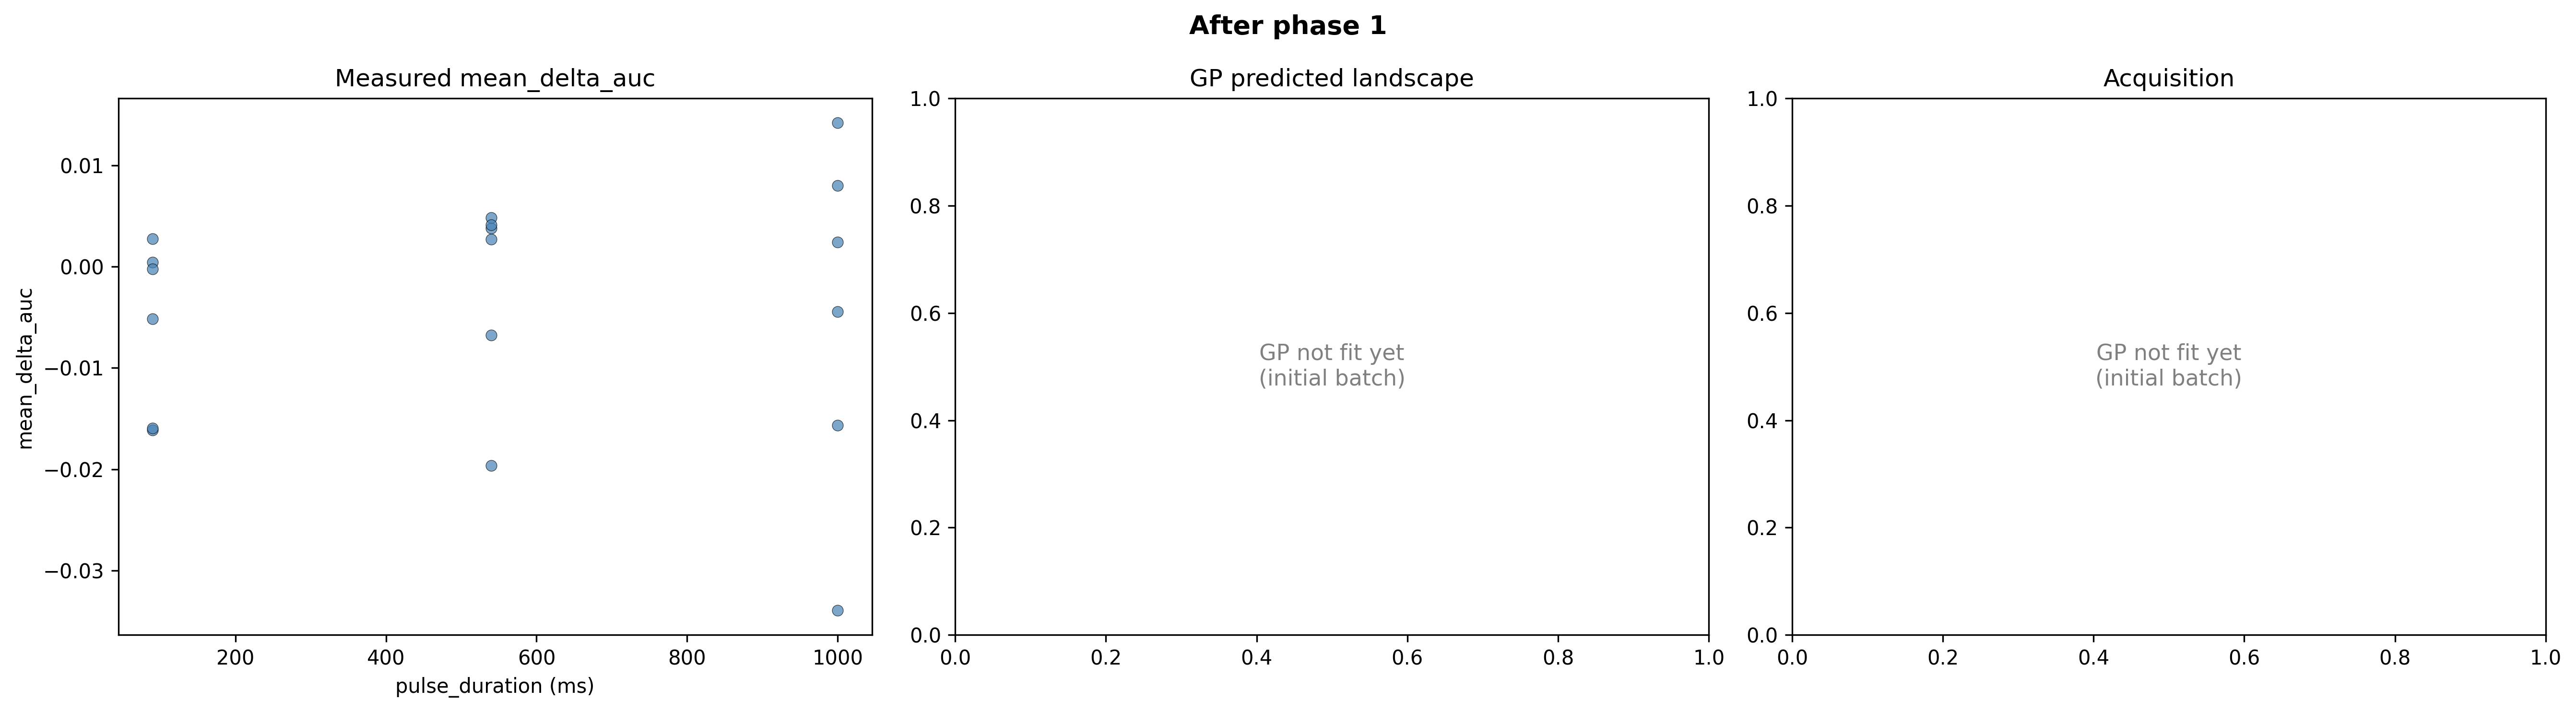


=== ComposedAgent: phase 2/5 ===
[FOVFinderAgent] Phase 1 — selected FOVs:
    B2_0000: 42 cells
    B2_0001: 118 cells
    B2_0002: 153 cells
    B3_0000: 104 cells
    B3_0001: 140 cells
    B3_0002: 156 cells
    B4_0000: 92 cells
    B4_0001: 131 cells
    B4_0002: 137 cells
    B5_0000: 136 cells
    B5_0001: 167 cells
    B5_0002: 195 cells
    B6_0000: 127 cells
    B6_0001: 128 cells
    B6_0002: 156 cells
    B7_0000: 131 cells
    B7_0001: 164 cells
    B7_0002: 184 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: fitting candidate 'hill']
    [auc: fitting candidate 'exponential']
    [auc: fitting candidate 'linear']
    [auc: phase log-evidence: hill=-13.848, exponential=-13.690, linear=-13.205]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: fitting candidate 'hill']
    [frac: fitting candidate 'exponential']
    [frac: fitting candidate 'linear']
    [frac: phase log-evidence: hill=+37.938, exponential=+34

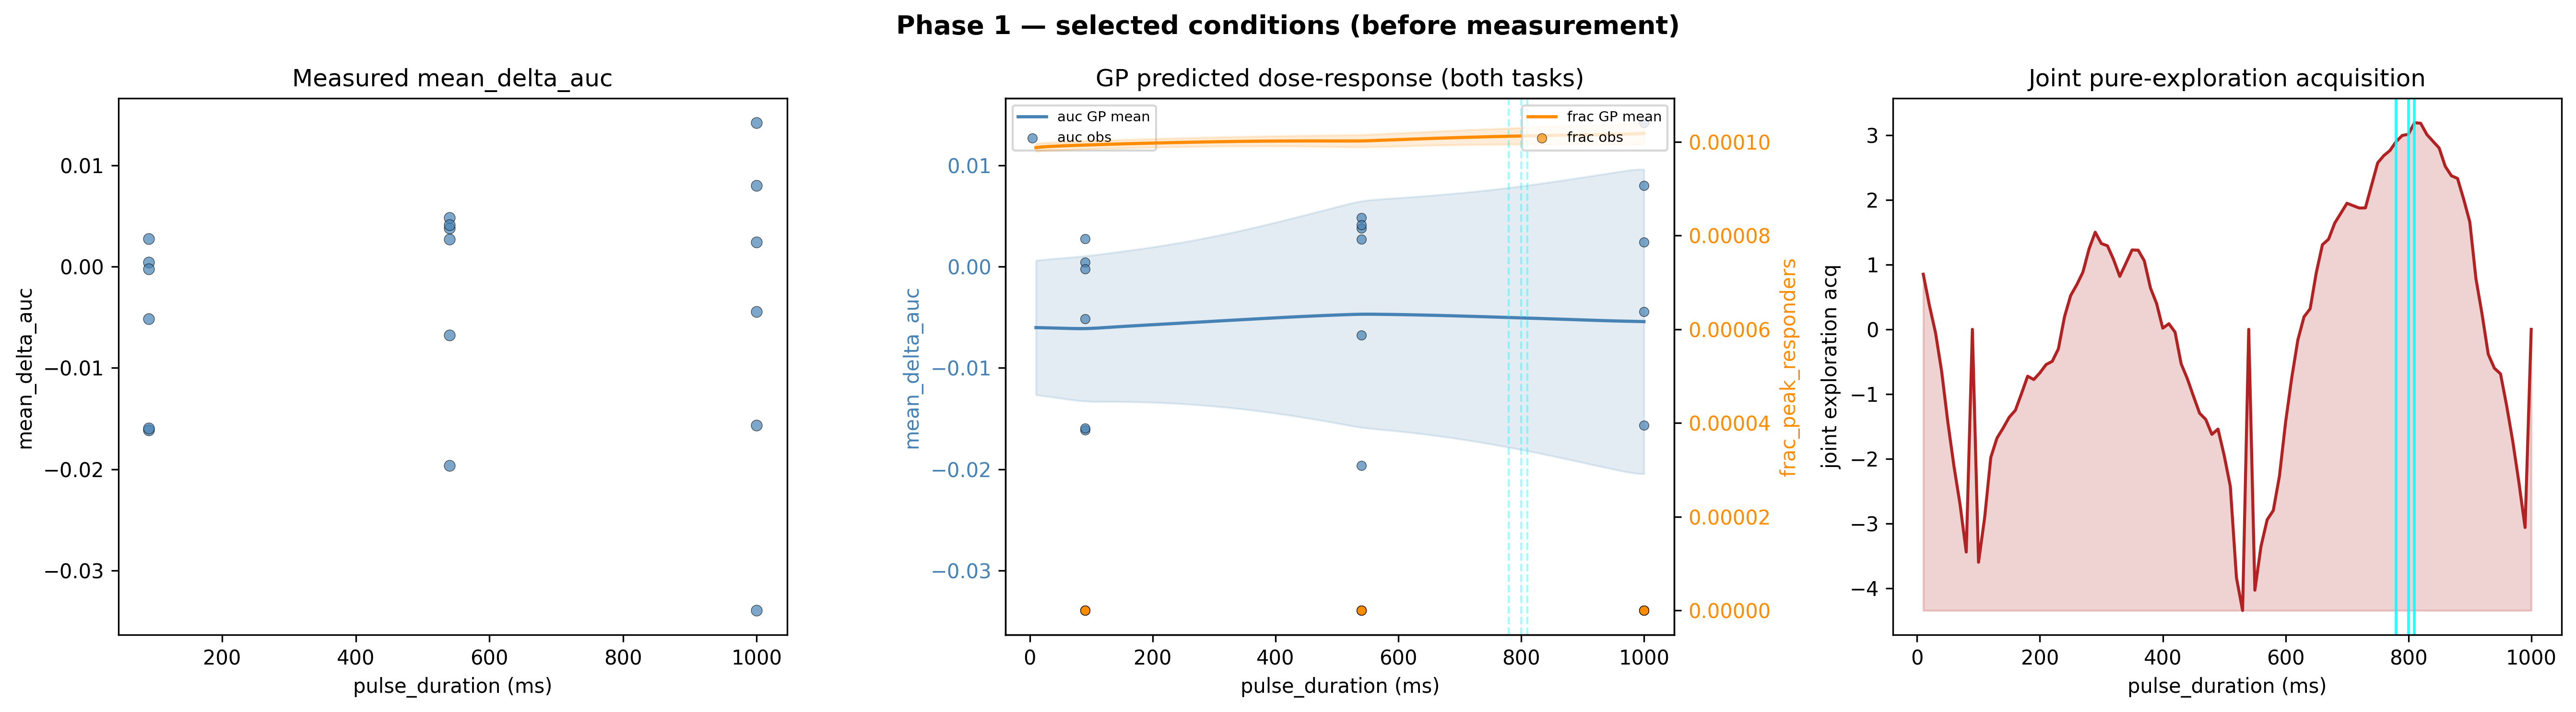

  Created 90 events for phase 1
    Cond 0 (FOVs 18-23): pulse_duration=810ms
    Cond 1 (FOVs 24-29): pulse_duration=780ms
    Cond 2 (FOVs 30-35): pulse_duration=800ms


In [ ]:
# Disconnect napari live view so it doesn't fight the acquisition engine.
try:
    mm_wdg._core_link.cleanup()
except Exception:
    pass

composed_agent.run()

In [ ]:
# --- Quick verification of the things this notebook is supposed to test ---
df = agent.df_results
print(f"df_results: {len(df)} rows")
if len(df) > 0:
    print("\noptortk_expression column:")
    print(
        f"  min={df['optortk_expression'].min():.3f}  "
        f"max={df['optortk_expression'].max():.3f}  "
        f"n_zeros={(df['optortk_expression'] <= 0).sum()}"
    )
    print("\nper-task selected hypothesis:")
    for task in agent.TASKS:
        s = agent._task_state[task]
        print(
            f"  {task}: locked={s['selected_hypothesis']!r}  "
            f"cumulative log-evidence={s['cumulative_log_evidence']}"
        )
    print("\nGP fits per task (sanity-check predict path):")
    if agent._gp_models_by_task:
        import gpax.utils

        rng_key, rng_key_pred = gpax.utils.get_keys()
        x_test = np.asarray(agent.x_total_linespace[:5], dtype=float)
        cov_vals = df[[c.name for c in agent.bo_covariates]].to_numpy(dtype=float)
        cov_mean = cov_vals.mean(axis=0, keepdims=True)
        x_full = np.hstack([x_test, np.tile(cov_mean, (len(x_test), 1))])
        x_full_scaled = agent._x_scaler.transform(x_full)
        for task, gp in agent._gp_models_by_task.items():
            try:
                _y, _ = gp.predict(rng_key_pred, x_full_scaled, noiseless=True)
                print(
                    f"  {task}: predict OK, first 5 preds = {np.asarray(_y).round(3)}"
                )
            except Exception as e:
                print(f"  {task}: predict FAILED -- {type(e).__name__}: {e}")

    print("\ndose-response scatter:")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].scatter(df["pulse_duration"], df["mean_delta_auc"], s=30, alpha=0.7)
    ax[0].set_xlabel("pulse_duration (ms)")
    ax[0].set_ylabel("mean_delta_auc")
    ax[0].set_title("AUC task")
    ax[1].scatter(df["pulse_duration"], df["frac_peak_responders"], s=30, alpha=0.7)
    ax[1].set_xlabel("pulse_duration (ms)")
    ax[1].set_ylabel("frac_peak_responders")
    ax[1].set_title("Frac task")
    plt.tight_layout()
    plt.show()
else:
    print("No data collected.")